In [23]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
import os

In [24]:
folder_path = "C:/Users/aliza/Downloads/wiresharkcapture"

all_data = []

for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        label = os.path.splitext(filename)[0]
        file_path = os.path.join(folder_path, filename)

    try:
        df = pd.read_csv(file_path)
        df['Label'] = label
        all_data.append(df)
    except Exception as e:
        print(f"Error loading {filename}: {e}")

df = pd.concat(all_data, ignore_index=True)

In [25]:
'''attack_path = "C:/Users/aliza/Downloads/wiresharkcapture/syn_flood.csv"
normal_path = "C:/Users/aliza/Downloads/wiresharkcapture/Normal_combined.csv"
attack_df = pd.read_csv(attack_path)
normal_df = pd.read_csv(normal_path)

attack_df['Label'] = 1
normal_df['Label'] = 0

df = pd.concat([attack_df, normal_df], ignore_index=True)'''

'attack_path = "C:/Users/aliza/Downloads/wiresharkcapture/syn_flood.csv"\nnormal_path = "C:/Users/aliza/Downloads/wiresharkcapture/Normal_combined.csv"\nattack_df = pd.read_csv(attack_path)\nnormal_df = pd.read_csv(normal_path)\n\nattack_df[\'Label\'] = 1\nnormal_df[\'Label\'] = 0\n\ndf = pd.concat([attack_df, normal_df], ignore_index=True)'

In [26]:
df = df.drop(['src_ip', 'dst_ip', 'timestamp'], axis=1)

In [27]:
'''
selectied_columns = [
    "flow_duration",
    "tot_fwd_pkts",
    "tot_bwd_pkts",
    "totlen_fwd_pkts",
    "totlen_bwd_pkts",
    "flow_byts_s",
    "flow_pkts_s",
    "pkt_len_mean",
    "fwd_pkt_len_mean",
    "bwd_pkt_len_mean",
    "Label"
]
df = df[selectied_columns]
'''

'\nselectied_columns = [\n    "flow_duration",\n    "tot_fwd_pkts",\n    "tot_bwd_pkts",\n    "totlen_fwd_pkts",\n    "totlen_bwd_pkts",\n    "flow_byts_s",\n    "flow_pkts_s",\n    "pkt_len_mean",\n    "fwd_pkt_len_mean",\n    "bwd_pkt_len_mean",\n    "Label"\n]\ndf = df[selectied_columns]\n'

In [28]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

In [29]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
)
model.fit(X_train_scaled, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [33]:
model.save_model("models/xgb_multiclass_model.json")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")

['models/label_encoder.pkl']

In [34]:
df['Label'].value_counts()

Label
5    65540
6    65539
0    30940
4     5597
3     2022
2     2004
1     2003
Name: count, dtype: int64

In [35]:
y_pred = model.predict(X_test_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.5f}')
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 99.98848

Classification Report:
                    precision    recall  f1-score   support

  Normal_combined       1.00      1.00      1.00      6143
    nmap_syn_scan       1.00      1.00      1.00       424
os_fingerprinting       1.00      1.00      1.00       404
        slowloris       1.00      1.00      1.00       395
  ssh_brute_force       1.00      1.00      1.00      1106
        syn_flood       1.00      1.00      1.00     13108
        udp_flood       1.00      1.00      1.00     13149

         accuracy                           1.00     34729
        macro avg       1.00      1.00      1.00     34729
     weighted avg       1.00      1.00      1.00     34729



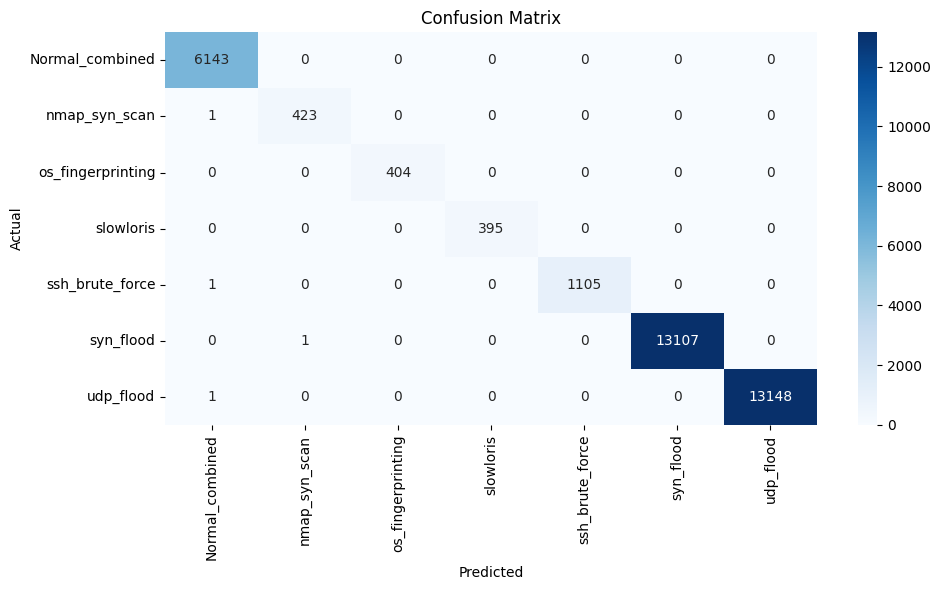

In [36]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()